<a href="https://colab.research.google.com/github/konishogu/DeepLearning/blob/main/EVALUACION_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



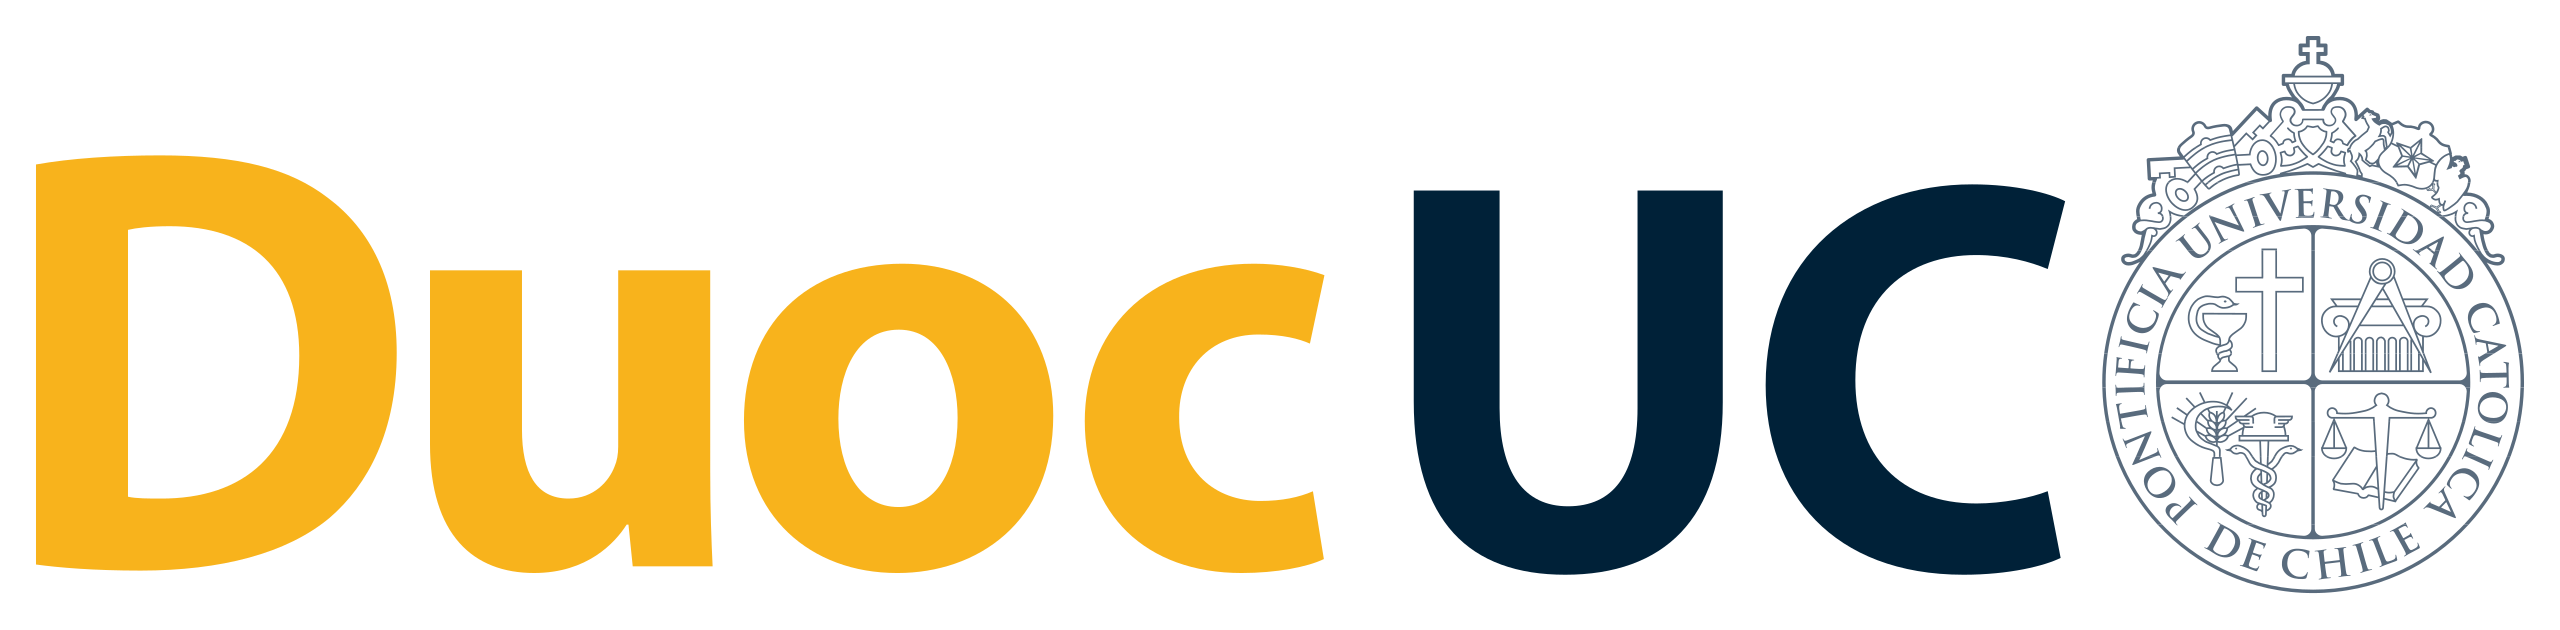



Deep Learning: Evaluacion 1

Autores:

    Matias

    Alejanda

    Luis Mendez

    Rodrigo Carcamo

Fecha de entrega:

    24-04-2026


## **Introducción**
En el presente trabajo se aborda el desarrollo de un modelo de Deep Learning utilizando una red neuronal multicapa (MLP) con el objetivo de resolver un problema de clasificación de imágenes. Para ello, se emplea el dataset Fashion-MNIST, el cual contiene imágenes en escala de grises de distintas prendas de vestir, tales como camisetas, pantalones, zapatos y bolsos.

Este conjunto de datos está compuesto por imágenes de tamaño 28x28 píxeles, organizadas en 10 clases diferentes, lo que lo convierte en un problema de clasificación multiclase. Cada imagen representa una prenda específica, y el objetivo del modelo es aprender a identificar correctamente la categoría a la que pertenece cada una.

El propósito principal de este trabajo es diseñar, entrenar y evaluar un modelo basado en redes neuronales artificiales, aplicando técnicas fundamentales de Deep Learning como el preprocesamiento de datos, la selección de funciones de activación, la optimización de hiperparámetros y la evaluación mediante métricas como accuracy, precision, recall y F1-score.

Adicionalmente, se realizarán experimentos controlados para analizar el impacto de distintos parámetros del modelo, tales como la tasa de aprendizaje, el número de épocas y el tamaño del batch, con el fin de mejorar su desempeño y comprender su comportamiento durante el proceso de entrenamiento.



## **Fase 1: Preprocesamiento de datos**

### **1. Cargar los datos**

En esta sección se han definido tres herramientas fundamentales para el desarrollo de la red neuronal artificial (MLP).

1. Tensorflow es la base que permite a la red neuronal aprender a partir de los datos, ya que se encarga de realizar los cáculos necesarios para ajustar los parámetros del modelo (pesos y bias) y mejorar sus predicciones con el tiempo. Sin esta librería, el entrenamiento sería mucho más complejo, ya que habría que implementar manualmente todos estos procesos.

2. Matplotlib se usa para visualizar tanto los datos como los resultados del modelo. Gracias a esta herramienta es posible representar imágenes y gráficos de forma clara, lo que facilita entender el comportamiento del entrenamiento y detectar posibles problemas. Sin esto, el análisis se limitaría a valores numéricos, dificultando la interpretación.

3. Keras reduce la complejidad de desarrollo, ofreciendo funciones listas para definir, entrenar y evaluar el modelo de manera simple y estructurada, permitiendo enfocar el trabajo en el diseño del modelo y el análisis de resultados, en lugar de implementar cada componente desde cero.

In [ ]:
# Importaciones necesarias

# Permite trabajar con redes neuronales
import tensorflow as tf

# Permite visualizar graficos e imágenes
import matplotlib.pyplot as plt

# Permite construir y entrenar modelos
from tensorflow import keras

Al ejecutar el código se obtiene la versión de TensorFlow instalada en el entorno, permitiendo asegurar que las funciones a utilizar sean compatibles y funcionen correctamente.

In [ ]:
# Verificar versión de TensorFlow
print(f"{tf.__version__}")

2.19.0


En este apartado, el código permite acceder al dataset Fashion-MNIST desde Keras y cargarlo en el entorno de trabajo. Este conjunto de datos se encuentra previamente dividido en dos partes: un conjunto de entrenamiento, utilizado para que la red neuronal aprenda patrones, y un conjunto de prueba, que se emplea para evaluar el rendimiento del modelo con datos que no ha visto anteriormente.

- Mediante el uso de .shape, se imprime la forma de cada conjunto de datos. Esto permite verificar que la carga se realizó correctamente, conocer la cantidad de imágenes disponibles y entender cómo están organizadas.

- En total, se cargan 70.000 imágenes, de las cuales 60.000 corresponden al entrenamiento y 10.000 a la prueba. Cada imagen está representada como una matriz de 28 x 28 píxeles y se almacena en las variables "x", mientras que sus respectivas etiquetas, es decir, la categoría de la prenda se guardan en las variables "y".

- El nombre X_train_full se utiliza para indicar que este es el conjunto de entrenamiento completo, el cual posteriormente será dividido para generar un subconjunto de validación en la siguiente fase.

In [ ]:
# Acceder al dataset
fashion_mnist = keras.datasets.fashion_mnist

# Separar en datos de entrenamiento y prueba
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Verificar la forma de los datos cargados
print(f"------------------------------------------------")
print(f"Imágenes de entrenamiento: {X_train_full.shape}")
print(f"------------------------------------------------")
print(f"Etiquetas de entrenamiento: {y_train_full.shape}")
print(f"------------------------------------------------")
print(f"Imágenes de prueba: {X_test.shape}")
print(f"------------------------------------------------")

------------------------------------------------
Imágenes de entrenamiento: (60000, 28, 28)
------------------------------------------------
Etiquetas de entrenamiento: (60000,)
------------------------------------------------
Imágenes de prueba: (10000, 28, 28)
------------------------------------------------


Al cargar el dataset Fashion-MNIST, las etiquetas y_train_full no están representadas como nombres de prendas (ej: “zapato” o “camisa”), sino como valores numéricos enteros entre 0 y 9. Para el modelo, estos números son suficientes, ya que trabaja con estas representaciones, sin embargo, para ser interpretados no entregan un significado claro por sí solos. Por esta razón, se define la lista “class_names”, que actúa como un diccionario entre cada valor numérico y su categoría correspondiente. Cada posición de la lista representa exactamente la etiqueta asignada por los creadores del dataset, tal como se especifica en la documentación oficial.

Esta decisión permite dar contexto a los datos y facilitar su interpretación. Por ejemplo, al visualizar una imagen, se puede mostrar su etiqueta en texto y verificar si el modelo está clasificando correctamente o si confunde clases, como un “abrigo” (coat) con un “vestido” (dress). Sin esta correspondencia, solo se observarían errores entre números, dificultando el análisis.

In [ ]:
# Definir los nombres de las categorías
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

### **2. Exploración del set de datos**

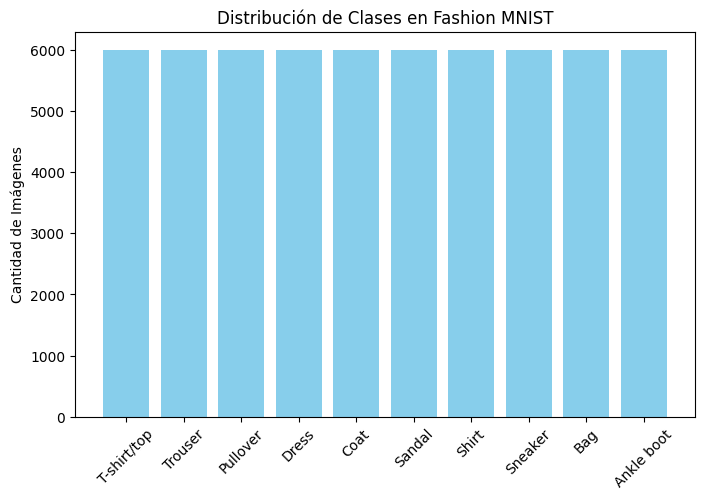

In [ ]:
import numpy as np

# Calcular la frecuencia de cada clase
unique, counts = np.unique(y_train_full, return_counts=True)

# Crear la visualización
plt.figure(figsize=(8, 5))
plt.bar(class_names, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title("Distribución de Clases en Fashion MNIST")
plt.ylabel("Cantidad de Imágenes")
plt.show()

*Justificación código*

Se está utilizando np.unique con el parámetro return_counts =True para extraer la frecuencia exacta de cada una de las 10 categorías en el dataset, luego hacemos uso de la librería matplotlib para generar un gráfico de barras para poder tener otra forma de visualizar las categorías del dataset con la cantidad de datos que contienen, también se hace uso de este modo de visualización para detectar posibles sesgos en los datos de entrenamiento ya que si una red neuronal se entrena con un dataset donde una clase tiene muchas más muestras que otra el modelo va a desarrollar un sesgo hacia la clase con mayor datos.

In [ ]:
# Revisión de valores nulos
def check_missing_values(x_train, x_test):
    print("--- Verificación de Valores Nulos ---")

    # En arreglos de NumPy, usamos np.isnan()
    # .sum() contará cuántos True (nulos) existen
    nulos_train = np.isnan(x_train).sum()
    nulos_test = np.isnan(x_test).sum()

    print(f"Valores nulos en set de entrenamiento: {nulos_train}")
    print(f"Valores nulos en set de prueba: {nulos_test}")

    # También es útil revisar si hay valores infinitos (raro en imágenes, pero posible)
    infinitos_train = np.isinf(x_train).sum()
    print(f"Valores infinitos en entrenamiento: {infinitos_train}")

# Llamada a la función
check_missing_values(X_train_full, X_test)

--- Verificación de Valores Nulos ---
Valores nulos en set de entrenamiento: 0
Valores nulos en set de prueba: 0
Valores infinitos en entrenamiento: 0


### **3. Escalado**

-------------------------------------------------------
Clase de la muestra: Ankle boot (ID: 9)
-------------------------------------------------------


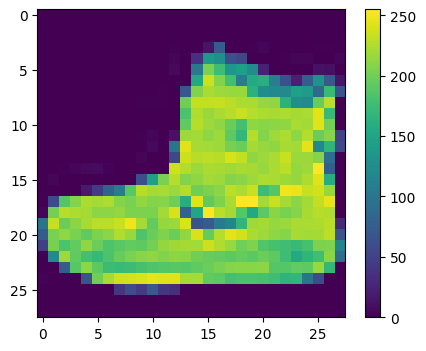

In [ ]:
# Configurar la impresión para ver la matriz completa
np.set_printoptions(linewidth=200)

print(f"-------------------------------------------------------")
print(f"Clase de la muestra: {class_names[y_train_full[0]]} (ID: {y_train_full[0]})")
print(f"-------------------------------------------------------")

plt.figure(figsize=(5,4))
plt.imshow(X_train_full[0])
plt.colorbar()
plt.grid(False)
plt.show()

Se importan las librerías utilizando Matplotlib para hacer gráficos e imágenes. Se crea una ventana donde se muestra la primera imagen del dataset x_train[0), junto con una barra de colores que permite visualizar la intensidad de los píxeles, la cual va de 0 a 255. La imagen corresponde a una prenda (zapatilla) y tiene un tamaño de 28x28 píxeles. Visualizar esto permite entender cómo están estructurados los datos antes de su procesamiento.

In [ ]:
# Mostrar la "verdad" de la computadora (los números)
print(f"-------------------------------------------------------")
print(f"Clase de la muestra: {class_names[y_train_full[0]]} (ID: {y_train_full[0]})")
print(f"-------------------------------------------------------")
print("Matriz de píxeles de la imagen:")
print(f"-------------------------------------------------------")
print(X_train_full[0])

-------------------------------------------------------
Clase de la muestra: Ankle boot (ID: 9)
-------------------------------------------------------
Matriz de píxeles de la imagen:
-------------------------------------------------------
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0   0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62  54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134 144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 

Esta es una representación numérica de la imagen, junto con su identificador (ID 9). Se visualiza la matriz de píxeles que la compone, la cual contiene valores entre 0 y 255. Esta representación permite entender cómo la computadora interpreta las imágenes. A partir de esta matriz, se puede identificar el rango en el que se encuentran los datos, lo que resulta fundamental para aplicar posteriormente el proceso de normalización.

Los valores de los píxeles van de 0 a 255, lo que puede dificultar el aprendizaje de la red neuronal, ya que genera inestabilidad y hace que el entrenamiento sea más lento y menos preciso. Al trabajar con valores grandes, el modelo puede presentar dificultades para converger correctamente. Por esta razón, se realiza un escalado a un rango entre 0 y 1, lo que permite un entrenamiento más estable, eficiente y preciso.


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

Se dividen todos los valores de las imágenes por 255.0, pasando de un rango de 0 a 255 a un rango entre 0 y 1. Luego, se realiza el mismo proceso con los datos de prueba, de modo que ambos conjuntos queden en la misma escala. Esto se hace para que la red neuronal aprenda mejor, evitando problemas asociados a valores muy grandes y permitiendo que el entrenamiento sea más rápido y estable.

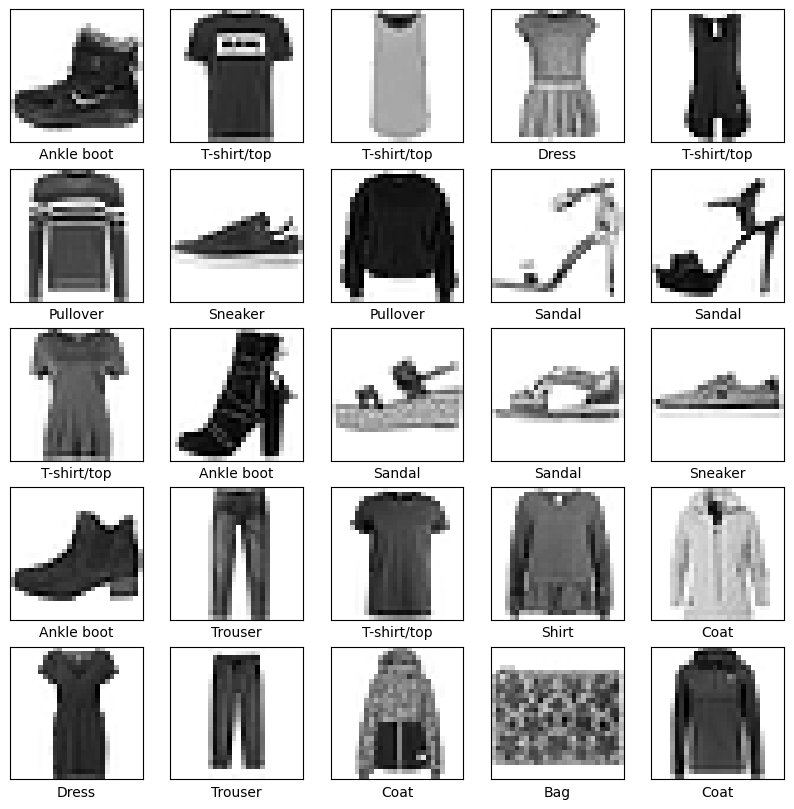

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

Una vez realizado el escalado, se visualiza un conjunto de 25 imágenes del dataset para comprobar que los datos mantienen su estructura original. Las imágenes se muestran en escala de grises y se etiquetan con su clase correspondiente. Esto permite confirmar que el proceso de normalización no altera la forma de las imágenes, sino únicamente la escala de sus valores.

## **Fase 2: Configuración**

In [ ]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## **Fase 3: Funciones core**

## **Fase 4: Optimización**

## **Fase 5: Evaluación**

## **Conclusión**